In [ ]:
# Install required libraries (Colab usually has them, but run once)
!pip install pandas numpy matplotlib seaborn streamlit

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
np.random.seed(42)

dates = pd.date_range(start="2024-01-01", end="2024-03-31")

categories = ["Food", "Travel", "Rent", "Shopping", "Bills", "Entertainment"]
payment_methods = ["Cash", "UPI", "Card"]

data = []

for _ in range(300):
    date = np.random.choice(dates)
    category = np.random.choice(categories)
    amount = np.random.randint(100, 5000)
    payment = np.random.choice(payment_methods)
    t_type = "Expense" if np.random.rand() > 0.2 else "Income"

    data.append([date, category, amount, payment, t_type])

df = pd.DataFrame(data, columns=["Date", "Category", "Amount", "Payment", "Type"])

df.head()

,Date,Category,Amount,Payment,Type
0,2024-02-21,Bills,3872,Cash,Income
1,2024-03-23,Rent,3544,Card,Income
2,2024-01-02,Shopping,2533,Cash,Expense
3,2024-02-27,Entertainment,4943,Cash,Expense
4,2024-02-28,Travel,2147,Card,Expense


In [ ]:
df.to_csv("expenses.csv", index=False)
print("✅ Dataset saved as expenses.csv")

✅ Dataset saved as expenses.csv


In [ ]:
df = pd.read_csv("expenses.csv")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Convert data types
df['Date'] = pd.to_datetime(df['Date'])
df['Amount'] = pd.to_numeric(df['Amount'])

# Standardize text
df['Category'] = df['Category'].str.strip().str.title()
df['Type'] = df['Type'].str.strip().str.title()

# Feature Engineering
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name()

df.head()

,Date,Category,Amount,Payment,Type,Month,Weekday
0,2024-02-21,Bills,3872,Cash,Income,February,Wednesday
1,2024-03-23,Rent,3544,Card,Income,March,Saturday
2,2024-01-02,Shopping,2533,Cash,Expense,January,Tuesday
3,2024-02-27,Entertainment,4943,Cash,Expense,February,Tuesday
4,2024-02-28,Travel,2147,Card,Expense,February,Wednesday


In [ ]:
# Category-wise spending
category_spend = df[df['Type'] == "Expense"].groupby('Category')['Amount'].sum().sort_values(ascending=False)

print("📊 Category-wise Spending:")
print(category_spend)

# Monthly spending
monthly_spend = df.groupby('Month')['Amount'].sum()

print("\n📅 Monthly Spending:")
print(monthly_spend)

📊 Category-wise Spending:
Category
Food             135296
Rent             113036
Travel           108287
Shopping          98571
Entertainment     89044
Bills             86722
Name: Amount, dtype: int64

📅 Monthly Spending:
Month
February    284444
January     300521
March       230455
Name: Amount, dtype: int64


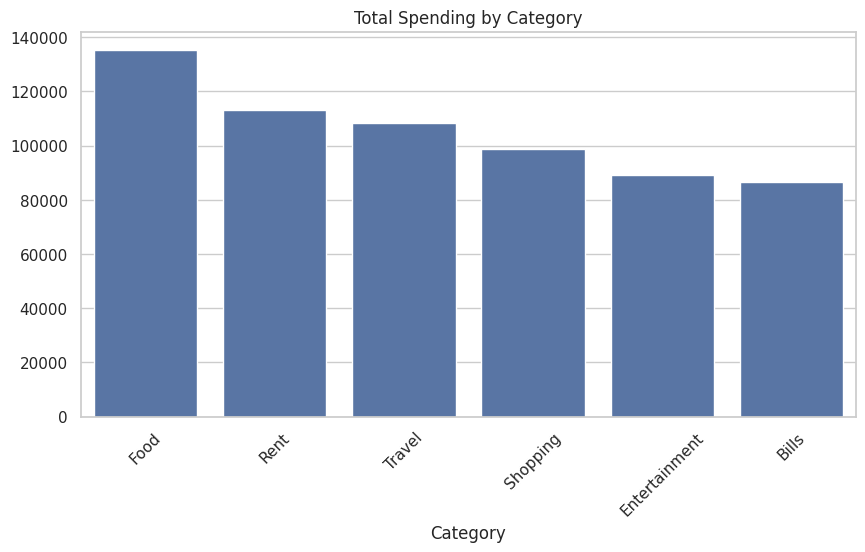

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=category_spend.index, y=category_spend.values)
plt.title("Total Spending by Category")
plt.xticks(rotation=45)
plt.show()

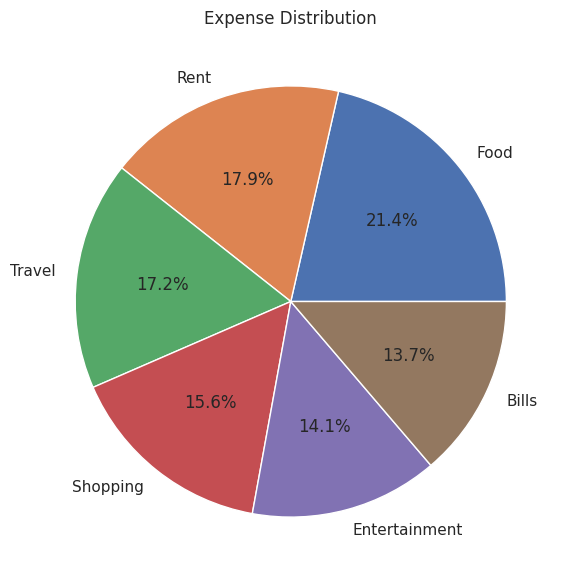

In [ ]:
plt.figure(figsize=(7,7))
plt.pie(category_spend, labels=category_spend.index, autopct='%1.1f%%')
plt.title("Expense Distribution")
plt.show()

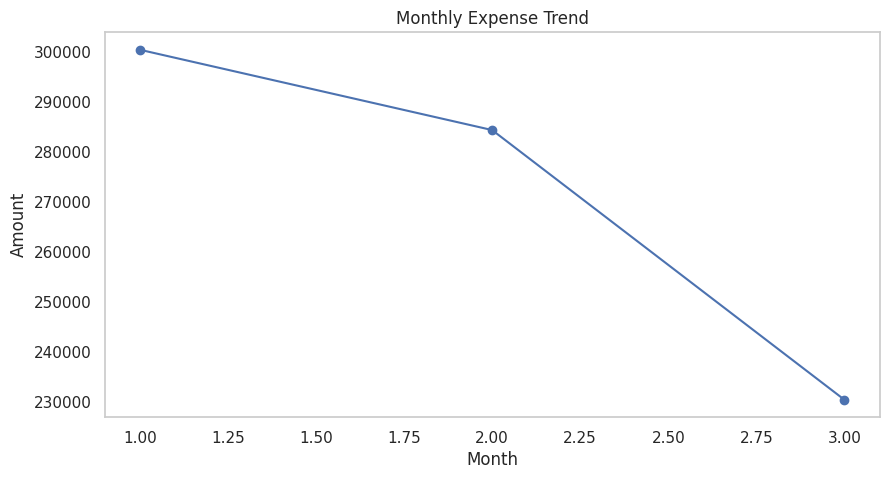

In [ ]:
df['Month_Num'] = df['Date'].dt.month

monthly_trend = df.groupby('Month_Num')['Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_trend, marker='o')
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid()
plt.show()

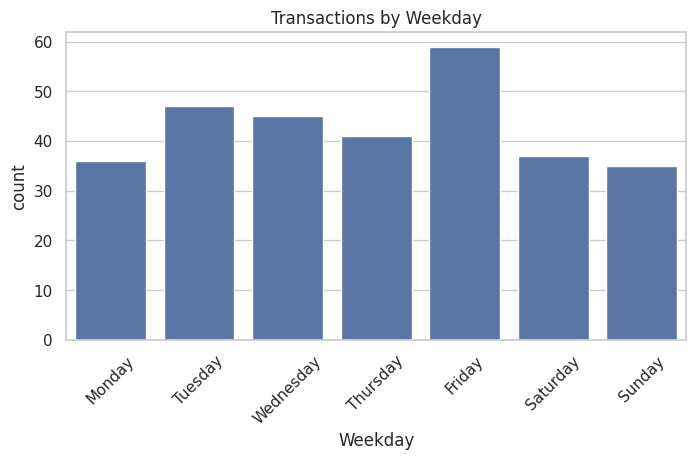

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Weekday', data=df,
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Transactions by Weekday")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("🔍 INSIGHTS:")

# Highest spending category
print("💰 Highest Spending Category:", category_spend.idxmax())

# Lowest spending
print("📉 Lowest Spending Category:", category_spend.idxmin())

# Average expense
print("📊 Average Transaction Amount:", df['Amount'].mean())

# Peak month
print("📅 Peak Spending Month:", monthly_trend.idxmax())

🔍 INSIGHTS:
💰 Highest Spending Category: Food
📉 Lowest Spending Category: Bills
📊 Average Transaction Amount: 2718.0666666666666
📅 Peak Spending Month: 1


In [ ]:
df.to_csv("cleaned_expenses.csv", index=False)
print("✅ Cleaned dataset saved!")

✅ Cleaned dataset saved!


In [ ]:
from google.colab import files

files.download("cleaned_expenses.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>